In [1]:
!pip install --upgrade pip
#!pip install matplotlib==3.0.3
!pip install matplotlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
pip install --upgrade matplotlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [3]:
!pip install Bio

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.6 MB/s eta 0:00:00


In [4]:
!pip install Levenshtein

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.4 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import sys
#sys.path.remove('/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common')
sys.path

['/content',
 '/env/python',
 '/usr/lib/python310.zip',
 '/usr/lib/python3.10',
 '/usr/lib/python3.10/lib-dynload',
 '',
 '/usr/local/lib/python3.10/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.10/dist-packages/IPython/extensions',
 '/root/.ipython']

In [7]:
import os
import sys
import glob
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

#sys.path.append('../common/')
py_file_location1 = "/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/A003_policy_optimization/"
sys.path.append(os.path.abspath(py_file_location1))

py_file_location2 = "/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common/"
sys.path.append(os.path.abspath(py_file_location2))

#import policy_evaluation
import data_io_utils
import paths
import utils
import constants
import plot_style_utils


import A003_common

%reload_ext autoreload
%autoreload 2

The module path: /content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common
S3 data root: /content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common/../../data/s3
EVO: /content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common/../../data/s3/evotuning_checkpoints
RANDOM: /content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common/../../data/s3/evotuning_checkpoints/1900_weights_random
A003


## First generate dataset summary figures

In [8]:
# data_io_utils.sync_s3_path_to_local(paths.SARKISYAN_SPLIT_2_FILE, is_single_file=True)
# data_io_utils.sync_s3_path_to_local(paths.SYNTHETIC_NEIGH_SPLIT_2_FILE, is_single_file=True)
# data_io_utils.sync_s3_path_to_local(paths.FP_HOMOLOGS_GEN_SPLIT_2_FILE, is_single_file=True)

# # Auxilliary files 
# data_io_utils.sync_s3_path_to_local(paths.SYNTHETIC_NEIGH_PARENTS_INFO_FILE, is_single_file=True)

In [9]:
paths

<module 'paths' from '/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/analysis/common/paths.py'>

In [10]:
#sark_df = pd.read_csv(paths.SARKISYAN_SPLIT_2_FILE)
sark_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/data/sarkisyan_split_2.csv')

"Simplify" synthetic neighborhoods and FP homologs datasets

In [11]:
#sn_df = pd.read_csv(paths.SYNTHETIC_NEIGH_SPLIT_2_FILE)
sn_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/data/Exp4-8_inferred_brightness_parents_assigned_split_2.csv')
#fp_df = pd.read_csv(paths.FP_HOMOLOGS_GEN_SPLIT_2_FILE)
fp_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Marjan/Low N/data/fp_homologs_data_dist_split_2.csv')

fused_df = A003_common.generate_simplified_and_fused_gen_set(sn_df, fp_df)

sn_df: (32953, 4)
fp_df: (3510, 7)
FP homolog parents contained in gen set: 0


In [12]:
simple_sn_df = fused_df[fused_df['gen_set'] == 'simple_syn_neigh']
simple_fp_df = fused_df[fused_df['gen_set'] == 'simple_fp_homologs']
simple_fp_df['quantitative_function'] = (
    simple_fp_df['quantitative_function'] - np.min(simple_fp_df['quantitative_function']))

display(simple_sn_df.head())
display(simple_fp_df.head())

<ipython-input-12-f6ee02f280fb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_fp_df['quantitative_function'] = (


,seq,quantitative_function,gen_set
0,MRKGEELFTGFVTILVELDGDVNGHKFSVRGEGEGDATNGKLTLCF...,1.448735e-01,simple_syn_neigh
1,MRKGEELFTGFVTILVELDGDVNGHKFSVRGEGEGDATNGKLTLEF...,1.448735e-01,simple_syn_neigh
2,MRKGEELFTGFVTILVELDGDVNGHKFSVRGEGEGDATNGKLTLEF...,1.448735e-01,simple_syn_neigh
3,MRKGEELFTGFVTILVELDGDVNGHKFSVRGEGEGDATNGKLTLEF...,2.007325e-07,simple_syn_neigh
4,MRKGEELFTGFVTILVELDGDVNGHKFSVRGEGEGDATNGKLTLEF...,2.007325e-07,simple_syn_neigh


,seq,quantitative_function,gen_set
16316,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.236565,simple_fp_homologs
16317,MSKGAELFTGIVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.142314,simple_fp_homologs
16318,MSKGEELFTGVVPILVELDGDVNGHKFSVRGEGEGDATYGKLTLKF...,0.246759,simple_fp_homologs
16319,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.142143,simple_fp_homologs
16320,MSKGEELFGGIVPILVELDGDVNGHQFSVSGEGEGDADYGKLEIKF...,0.169603,simple_fp_homologs


## Plot

Basic set up

In [13]:
plot_style_utils.set_pub_plot_context()

def cwhist(ax, data, drange, nbins=30, color='k'):
    hvals, bins = np.histogram(data, bins=nbins, range=drange, normed=True)
    bc = (bins[:-1] + bins[1:])/2
    ax.bar(bc, hvals, width=np.diff(drange)[0]/nbins, color=color)

In [14]:
def plot_dataset_summary(df):

    np.random.seed(1)
    random.seed(1)

    nsub = 200
    pidx = np.random.permutation(df.shape[0])[:nsub]
    iu = np.triu_indices(nsub, k=1)

    ld_av = utils.levenshtein_distance_matrix([constants.AVGFP_AA_SEQ], list(df['seq'])).reshape(-1)
    ld_pw = utils.levenshtein_distance_matrix(list(df['seq'].iloc[pidx]))
    ld_pw = ld_pw[iu]
    
    fig = plt.figure(figsize=(8,4))
    gs = fig.add_gridspec(2, 2)
    plt.rcParams.update({'font.size': 22})

    nmut_range = [0, 64]
    qfunc_range = [0, 2.95]

    ax1 = fig.add_subplot(gs[:,0])
    plot_style_utils.prettify_ax(ax1)
    cwhist(ax1, df['quantitative_function'], qfunc_range, nbins=20)
    ax1.set_yscale('log')
    ax1.set_yticks([])
    ax1.set_xlim(qfunc_range)
    ax1.set_xlabel('Log rel. fluorescence', fontsize=22)
    ax1.axvline(1, color='r', linestyle='--', zorder=-1)

    ax2 = fig.add_subplot(gs[0,1])
    plot_style_utils.prettify_ax(ax2)
    cwhist(ax2, ld_av, nmut_range, nbins=20)
    ax2.set_xlim(nmut_range)
    ax2.set_yticks([])
    ax2.set_xticks([])

    ax3 = fig.add_subplot(gs[1,1])
    plot_style_utils.prettify_ax(ax3)
    cwhist(ax3, ld_pw, nmut_range, nbins=20)
    ax3.set_yticks([])
    ax3.set_xlim(nmut_range)
    ax3.set_xlabel('Num. mutations', fontsize=22)
    
   

    plt.show()
    
    return fig

In [15]:
print(sark_df.shape)
print(simple_sn_df.shape)
print(simple_fp_df.shape)

(17238, 2)
(16316, 3)
(1594, 3)


<ipython-input-13-aa273c1d36f0>:4: VisibleDeprecationWarning: Passing `normed=True` on non-uniform bins has always been broken, and computes neither the probability density function nor the probability mass function. The result is only correct if the bins are uniform, when density=True will produce the same result anyway. The argument will be removed in a future version of numpy.
  hvals, bins = np.histogram(data, bins=nbins, range=drange, normed=True)


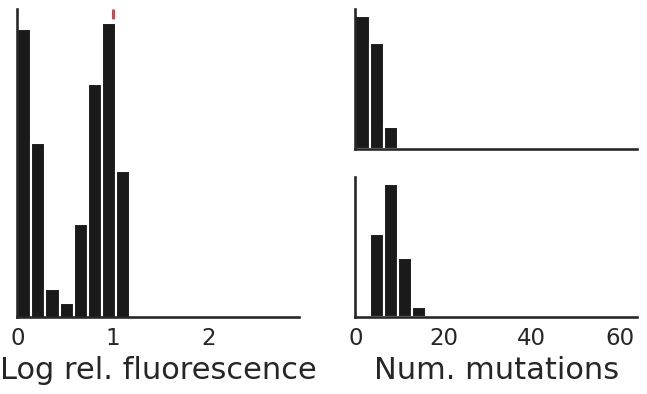

FileNotFoundError: ignored

In [16]:
fig = plot_dataset_summary(sark_df)
plot_style_utils.save_for_pub(fig, path="figures/sarkisyan_summary", dpi=300)

In [ ]:
fig = plot_dataset_summary(simple_sn_df)
plot_style_utils.save_for_pub(fig, path="figures/simple_syn_neigh", dpi=300)

In [ ]:
fig = plot_dataset_summary(simple_fp_df)
plot_style_utils.save_for_pub(fig, path="figures/simple_fp_homologs", dpi=300)